# Using neural visual classifers for VSA-TTR with the HD-Glue method

In this demo we'll use the HD-Glue [1] method for translating 
from dense neural representations to high-dimensional Binary Spatter Code (BSC)
embeddings.
We'll then train a VSA classifer and interpret the learned class representations
as giving the semantics for TTR types.

Only the last part is new, the first two parts just replicate [1].
The main objective to to assess the feasiblitiy of this method before trying to
add more strucutre to the VSA representations, with the ultimate goal of
representing situation types.

One additional complication we'll deal with is that [1] assume
a multi-class single-label classification scenerio (where the classifier chooses
among $N$ distinct classes). 
That ultimately won't work for us since we don't want to be limited to representing
a set of types that partition the world.
We'll adapt the CIFAR-10 dataset to a multi-label setting to see how it translates.

**[1]:** Sutor, Peter, Dehao Yuan, Douglas Summers-Stay, Cornelia Fermuller, and Yiannis Aloimonos. [Gluing Neural Networks Symbolically Through Hyperdimensional Computing](https://doi.org/10.1109/IJCNN55064.2022.9892622.) 2022 International Joint Conference on Neural Networks (IJCNN)


## CIFAR-10

CIFAR-10 is a simlpe 10-way visual classification task using 32x32 pixle images.

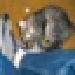

cat



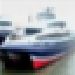

ship



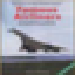

airplane



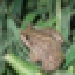

frog



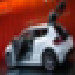

automobile



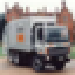

truck



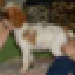

dog



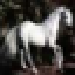

horse



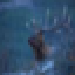

deer



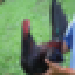

bird



In [1]:
from torchvision.datasets import CIFAR10
from torchvision.transforms import ToPILImage
from IPython.display import Image
import random

test_data = CIFAR10(root='./data', download=True, train=False)
labels = test_data.classes
n_classes = len(labels)

# show an example from each class
examples = []
for image, label in test_data:
    if any(label_ == label for _,label_ in examples):
        continue
    if len(examples) == 10:
        break
    examples.append((image, label))
    display(image.resize((75,75), resample=4))
    print(labels[label]+'\n')

## VGG16

For our dense neural representations, we will use the output second-to-last layer of a VGG-16 network that's pre-trained on the CIFAR-10 train set.
VGG is a stack of 16 convolutional layers (each with a batch normalization and ReLU activiation layer) followed by 3 linear layers. 

In [2]:
import torch

vgg = torch.hub.load(
    "chenyaofo/pytorch-cifar-models", 
    "cifar10_vgg16_bn", 
    pretrained=True
).eval()

print(vgg)

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (9): ReLU(inplace=True)
    (10): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (12): ReLU(inplace=True)
    (13): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (14): Conv2d(128, 256

Using cache found in /home/bill/.cache/torch/hub/chenyaofo_pytorch-cifar-models_master


### Sanity check: Testing the pre-trained VGG16 classifier

First let's just classify the example images from before.

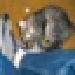

cat
cat (0.9999) dog (0.0000) frog (0.0000) bird (0.0000) deer (0.0000)



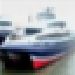

ship
ship (0.9997) airplane (0.0001) automobile (0.0001) truck (0.0000) bird (0.0000)



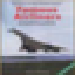

airplane
airplane (0.9996) ship (0.0001) bird (0.0001) cat (0.0001) automobile (0.0000)



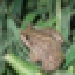

frog
frog (0.9998) bird (0.0001) cat (0.0000) deer (0.0000) dog (0.0000)



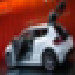

automobile
automobile (0.9997) truck (0.0001) dog (0.0000) ship (0.0000) airplane (0.0000)



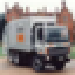

truck
truck (0.9999) automobile (0.0001) ship (0.0000) horse (0.0000) cat (0.0000)



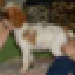

dog
dog (0.9999) cat (0.0000) horse (0.0000) deer (0.0000) automobile (0.0000)



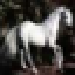

horse
horse (0.9999) dog (0.0000) deer (0.0000) truck (0.0000) cat (0.0000)



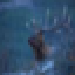

deer
deer (0.9922) airplane (0.0051) ship (0.0007) frog (0.0005) cat (0.0004)



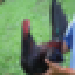

bird
bird (0.9999) cat (0.0000) frog (0.0000) airplane (0.0000) dog (0.0000)



In [3]:
from cifar10 import cifar10_transform
import torch.nn.functional as F

for image, label in examples:
    
    display(image.resize((75,75), resample=4))
    print(labels[label])

    # cifar10_transform replicates the feature normalization used in pre-training
    image_prepped = cifar10_transform(image).unsqueeze(0)
    # the model has no final activation built-in so we need to softmax to get predictions
    output = vgg(image_prepped)
    preds = F.softmax(output, dim=1)
    topk = torch.topk(preds, 5)
    print(' '.join([f"{labels[label]} ({p:0.4f})" for label, p in zip(topk.indices[0], topk.values[0])]))
    print()

Next we'll check the performance on the full CIFAR10 test set. This will give us a good sanity-check to make sure we don't loos too much performance when moving to the VSA classifier.

In [4]:
from train_cifar_classifiers import evaluate

test_data.transform = cifar10_transform
test_dataloader = torch.utils.data.DataLoader(
    test_data, 
    batch_size=256,
    shuffle=False, 
    num_workers=4)

loss, acc = evaluate(test_dataloader, vgg, multilabel=False)

Val loss:0.3555
           prc  rec  f1   support
airplane   0.92 0.95 0.94   1000
automobile 0.97 0.96 0.97   1000
bird       0.93 0.92 0.93   1000
cat        0.84 0.86 0.85   1000
deer       0.94 0.95 0.94   1000
dog        0.90 0.88 0.89   1000
frog       0.97 0.95 0.96   1000
horse      0.98 0.96 0.97   1000
ship       0.95 0.96 0.96   1000
truck      0.96 0.95 0.96   1000
mac. avg.  0.94 0.94 0.94


We see that the macro average precision, recall, and F1 are around `0.94` for the pre-trained VGG model. Since the final layer of the model (which takes the dense representation from `512` to `10`) is linear, this good performance implies that the `512`-dimensional embedding space of the second-to-final layer exhibits good linear separation between the classes. We'll use that layer as our input to HD-Glue.

In [5]:
def get_vgg_features(model, x):
    x = model.features(x)
    x = torch.flatten(x, 1)
    return model.classifier[:-3](x)

eg_image, eg_label = examples[0]
eg_image_prepped = cifar10_transform(eg_image).unsqueeze(0)
eg_image_dense = get_vgg_features(vgg, eg_image_prepped)
print(eg_image_dense.size()) # batch size = 1


torch.Size([1, 512])


## HD-Glue

### Encoding Neural Output Signals as Hypervectors (§IV.A in [1])
In summary, the HD-Glue method goes as follows:

1. Transform each of the `512` components of (for example) `eg_image_dense` into a symbolic vector according to its value. 
2. Bind the component value vectors to arbitrary (symbolic) component index vectors 
3. Bundle the result to get a single `4098` (or whatver size) HD vector.

BSC uses "concensus sum" for bundling -- for a set of vectors, take either 0 or 1 at each component depending on which is most common (if the cardinality of the set is even, add a random vector to the set).

The tricky part is #1, but it's dealt with as follows:

- 1a: Transform the logit output of the neural model to the $[-1,1]$ interval using TanH.
- 1b: Divide the $[-1,1]$ interval into `N` bins.
- 1c: Rerpresent the bins by _"slowly changing the hypervector for -1 into the hypervector for 1 with each additional bin, by randomly changing a constant number of unchanged bits"_ [1]. Specifically the authors refer to the method described in [2].

In the TorchHD library, this is called [a "level embedding"](https://torchhd.readthedocs.io/en/latest/generated/torchhd.embeddings.Level.html). It has the property that adjacent vectors are correlated, but far-away vectors aren't. I think this may be an implementation of the method used in [2] but I should double check that...

**[2]:** Ganesan, Ashwinkumar, Hang Gao, Sunil Gandhi, et al. [“Learning with Holographic Reduced Representations.”](https://papers.neurips.cc/paper_files/paper/2021/hash/d71dd235287466052f1630f31bde7932-Abstract.html). Advances in Neural Information Processing Systems 34 (2021)


In [6]:
import torchhd

dense_size = 512
hd_size = 2**12
component_buckets = 100

def concensus_sum(x):
    batch_size, n_items, hd_size = x.size()
    if n_items % 2 == 0: # break ties randomly
        r = torchhd.random(batch_size, hd_size, vsa='BSC')
    x = torch.cat((x, r.unsqueeze(1)), dim=1)
    threshold = n_items // 2
    return x.sum(1) > threshold

class HDGlue:

    def __init__(self, nn_dim, hd_size, n_bins):

        boundary_map = torch.vmap(lambda x: x/((n_bins-1)/2)-1)
        self.tanh_bounds = boundary_map(torch.LongTensor(range(n_bins)))
        self.component_ids = torchhd.random(nn_dim, hd_size, vsa='BSC')
        self.bin_reps = torch.stack([
            torchhd.level(n_bins, hd_size, vsa='BSC') 
                for _ in range(nn_dim)
        ])

    _embedding = staticmethod(torch.vmap(F.embedding, in_dims=0))

    def __call__(self, x):
        batch_size = x.size(0)
        # pointwise tanh features to [-1, 1]
        x = F.tanh(x)
        # compute bin for each tanh value
        x = torch.bucketize(x, self.tanh_bounds)
        # embed values using HD bin representations
        x = self._embedding(x.T, self.bin_reps).transpose(0,1)
        # bind component values to component IDs
        x = self.component_ids.repeat([batch_size, 1, 1]).bind(x)
        # concensus sum along the component dimension
        x = concensus_sum(x)
        return x

hd_glue = HDGlue(dense_size, hd_size, component_buckets)

hd_glue(eg_image_dense).shape

torch.Size([1, 4096])

### Training Hypervector Models for a Neural Network (§IV.B in [1])

In the end our "model" will be a single high-dimensional vector.

To classify images, we'll query the model by binding a HD-Glue-ified image vector and checking which class label vector is closest to the result.

$$ pred(M, x) = arg\, max_{i=1,...10} \sum_{j=1,...,2^{12}} (M\otimes x)_j = c_{i,j} $$

First we'll test a randomly initialized model.

In [7]:
import numpy as np
from sklearn.metrics import precision_recall_fscore_support

# randomly initialized VSA model
M = torchhd.random(1, hd_size, vsa='BSC').squeeze()

# random symbolic class vectors
class_ids = torchhd.random(n_classes, hd_size, vsa='BSC')

def evaluate_vsa_classifier(model, class_ids, dataloader, train_totals=None, n_batches=None):
    if train_totals is None:
        train_totals = [0] * len(dataloader.dataset.classes)
    true, pred = [], []
    for batch, (x, y) in enumerate(dataloader):
        true.append(y.detach().cpu().numpy())
        x_dense = get_vgg_features(vgg, x)
        x_hd = hd_glue(x_dense)
        # bind the input to the model
        x_hd_bound = torchhd.bind(M, x_hd)
        # compare the bound input to the class IDs
        corr = x_hd_bound.unsqueeze(1).repeat(1, n_classes, 1) == \
                class_ids.unsqueeze(0).repeat(x.size(0), 1, 1)
        # predict the class ID most similar to the bound input
        pred.append(corr.sum(-1).argmax(1))
        if n_batches and batch >= n_batches:
            break
    pred = np.concatenate(pred)
    true = np.concatenate(true)
    results = precision_recall_fscore_support(true, pred, zero_division=0)
    print(f"{' ':<10} {'prc':<4} {'rec':<4} {'f1':<4} {'support'} {'n_train'}")
    for i, (l, (p, r, f1, s)) in enumerate(zip(dataloader.dataset.classes, zip(*results))):
        nt = train_totals[i]
        print(f"{l:<10} {p:0.2f} {r:0.2f} {f1:0.2f} {s: 7d} {nt: 7d}")
    macro_p, macro_r, macro_f1, _ = map(np.mean, results)
    print(f"{'mac. avg.':<10} {macro_p:0.2f} {macro_r:0.2f} {macro_f1:0.2f}")

evaluate_vsa_classifier(M, class_ids, test_dataloader, n_batches=2)

           prc  rec  f1   support n_train
airplane   0.25 0.01 0.03      76       0
automobile 0.01 0.02 0.01      63       0
bird       0.11 0.10 0.11      78       0
cat        0.03 0.08 0.04      75       0
deer       0.00 0.00 0.00      67       0
dog        0.00 0.00 0.00      73       0
frog       0.00 0.00 0.00      90       0
horse      0.00 0.00 0.00      73       0
ship       0.06 0.24 0.09      83       0
truck      0.00 0.00 0.00      90       0
mac. avg.  0.05 0.05 0.03



To train the model we will learn a "prototype" vector for each class and bind it to a symbolic (random) class label vector.
The trained model consists in bondling those vectors together. 

$$ M = \bigoplus_{i=1,...,10}c_i \otimes l_i $$

To learn the prototype vectors, we simply consensus-sum the traninig vectors belonging to each class. We'll define a "compact" version of concensus sum that allows us to count the number of `True` values in each position, rather than keeping the whole batch of HD vectors in memory.

In [8]:

def compact_concensus_sum(x, total):
    even_total = (total + 1) % 2 # 1's for classes w/ even totals
    r = torchhd.random(x.size(0), x.size(1), vsa="BSC") # random tie-break vectors
    r = r * even_total.unsqueeze(1) # mask out random vectors for classes with odd totals
    total += even_total # add the counts for tie-breakers (all totals are odd now)
    x += r # add the actual tie-breaker vectors
    threshold = (total // 2).unsqueeze(1)
    return x > threshold

train_data = CIFAR10(
    root='./data', download=True, train=True, transform=cifar10_transform)
train_dataloader = torch.utils.data.DataLoader(
    train_data, batch_size=16, shuffle=False, num_workers=4)

We'll test on the same data as before and train in batches of 16 so that we can observe how quickly the training happens. The class prototypes stabalize extremely quickly. In some cases, just seeing one example is enough for good performance in a class.

## TTR-VSA

So what does this get us? We use `M` and `class_ids` to write a Python function that acts as a witness condition for the respective 10 types ... but of cours we could do that already with `vgg`. 

I'm hoping we can find a way to encode more structure in the high-dimein `M`

In [9]:
# count the number `True` values in each component for each class 
memory = torch.zeros((n_classes, hd_size), dtype=torch.long)
# count the number of examples seen for each class
memory_totals = torch.zeros(n_classes, dtype=torch.long)

for batch, (x, y) in enumerate(train_dataloader):

    x_feats = get_vgg_features(vgg, x)
    x_hd = hd_glue(x_feats)
    memory_totals += torch.bincount(y, minlength=n_classes)
    for i in range(n_classes):
        x_i = x_hd * (y == i).unsqueeze(1) # mask out other classes
        memory[i] += x_i.sum(dim = 0) # add component counts to memory
    prototypes = compact_concensus_sum(memory, memory_totals)
    
    M = concensus_sum(torchhd.bind(class_ids, prototypes).unsqueeze(0)).squeeze()
    evaluate_vsa_classifier(M, class_ids, test_dataloader, train_totals=memory_totals)

    if batch >= 5:
        break


           prc  rec  f1   support n_train
airplane   0.00 0.00 0.00    1000       1
automobile 0.98 0.94 0.96    1000       3
bird       0.89 0.92 0.90    1000       3
cat        0.52 0.91 0.66    1000       1
deer       0.97 0.91 0.94    1000       3
dog        0.00 0.00 0.00    1000       1
frog       0.94 0.91 0.93    1000       1
horse      0.48 0.98 0.64    1000       3
ship       0.97 0.95 0.96    1000       1
truck      0.73 0.95 0.82    1000       5
mac. avg.  0.65 0.75 0.68
           prc  rec  f1   support n_train
airplane   0.98 0.75 0.85    1000       3
automobile 0.98 0.94 0.96    1000       3
bird       0.98 0.77 0.86    1000       5
cat        0.39 0.96 0.56    1000       5
deer       0.91 0.96 0.94    1000       5
dog        0.00 0.00 0.00    1000       3
frog       0.74 0.93 0.83    1000       5
horse      0.99 0.94 0.97    1000       3
ship       0.99 0.83 0.90    1000       1
truck      0.97 0.94 0.95    1000       7
mac. avg.  0.80 0.80 0.78
           prc  rec  f1 